In [176]:
pip install seaborn

In [177]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [178]:
df = pd.read_csv('data-a2-p1.csv')


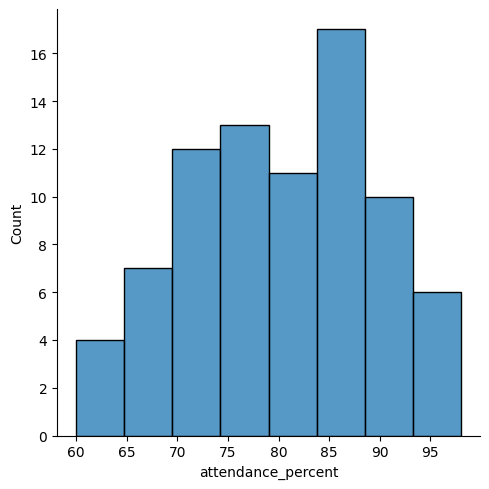

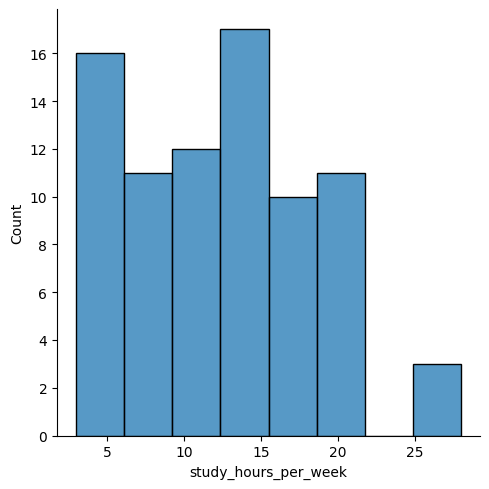

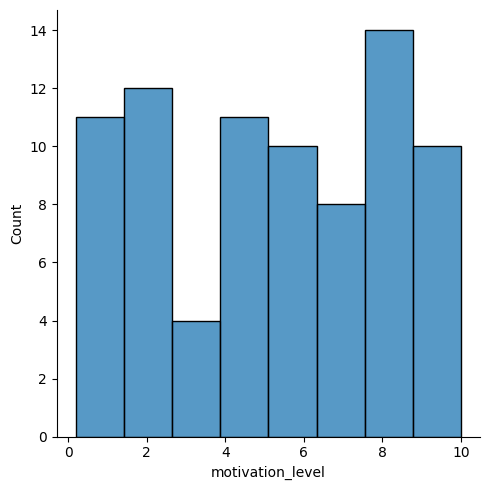

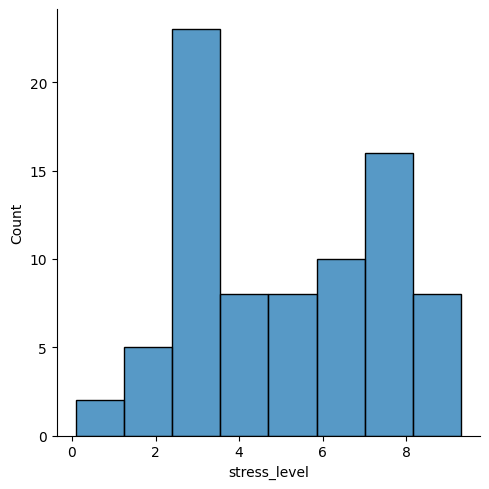

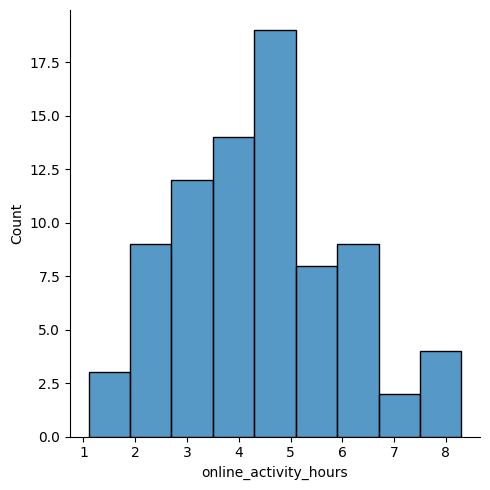

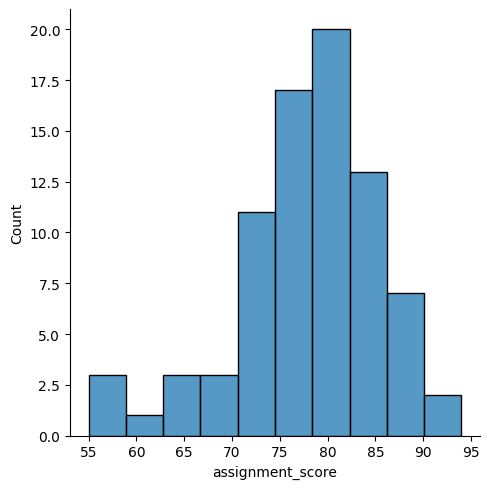

In [179]:
# Problem 1a)

for column in df.columns.drop('student_id'):
    sns.displot(df, x=column)

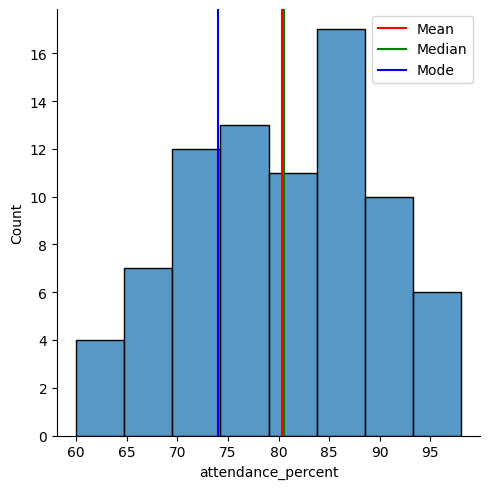

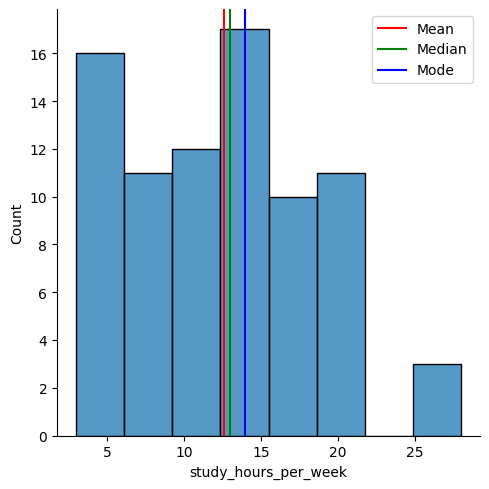

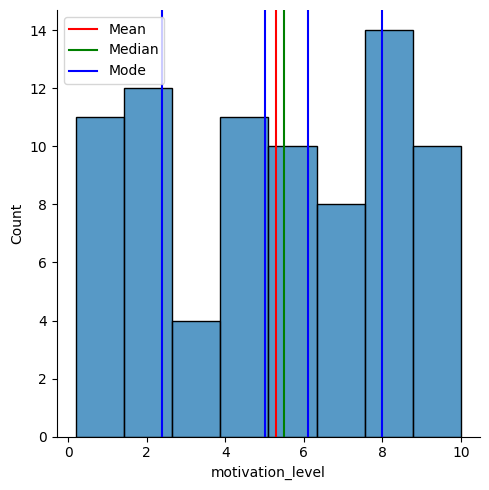

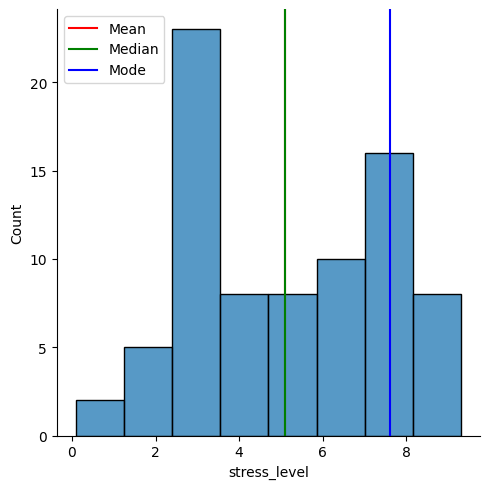

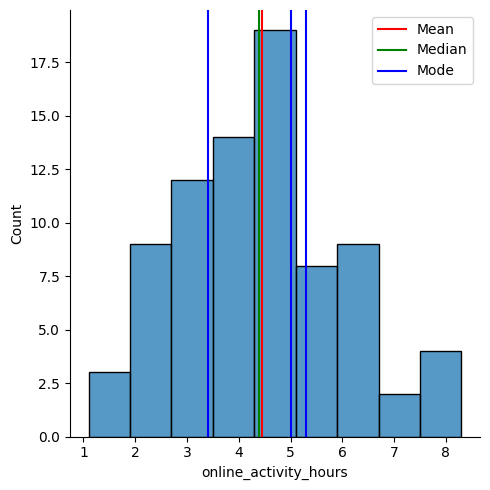

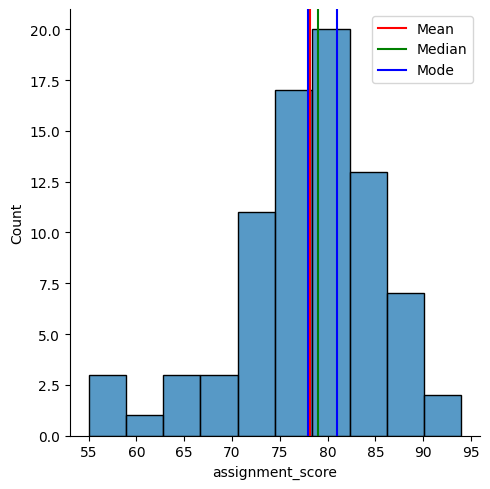

In [180]:
# Problem 1b)
for column in df.columns.drop('student_id'):
    sns.displot(df, x=column)
    plt.axvline(x=df[column].mean(), color='red', label='Mean')
    plt.axvline(x=df[column].median(), color='green', label='Median')
    is_mode_in_legend = False
    for mode in df[column].mode():
      if not is_mode_in_legend:
        plt.axvline(x=mode, color='blue', label='Mode')
        is_mode_in_legend = True
      else:
        plt.axvline(x=mode, color='blue')
    plt.legend()

Problem 1C)

- attendance_percent resembles a bimodal, neutral skew/non-tailed distribution.
- study_hours_per_week resembles a bimodal, positive skew/right-tailed distribution.
- motivation_level resembles a multimodal distribution.
- stress_level resembles a bimodal distribution.
- online_activity_hours resembles a unimodal distribution with neutral skew/non-tailed distribution.

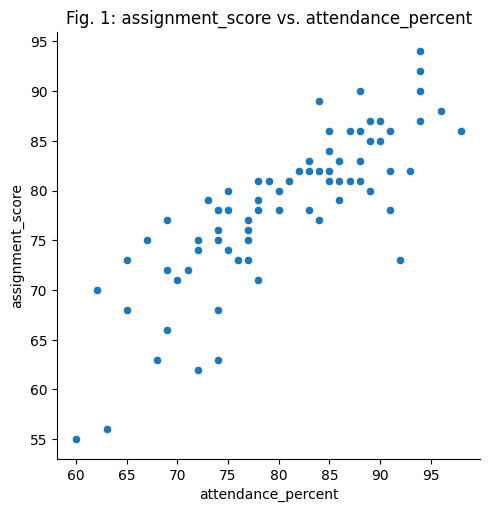

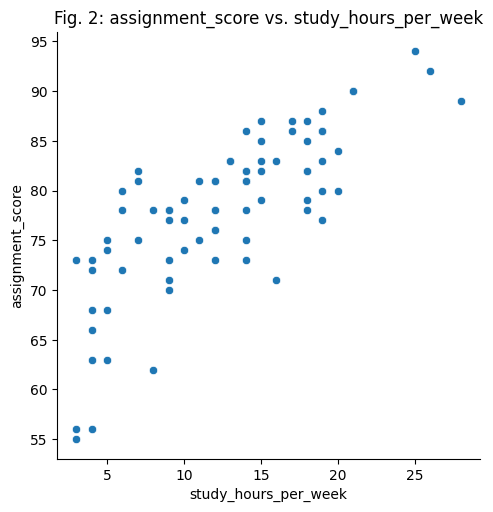

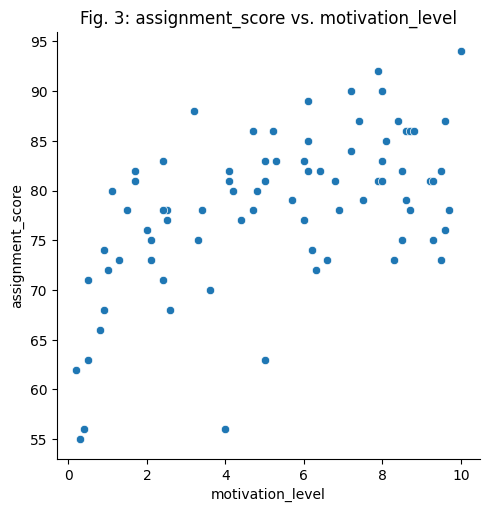

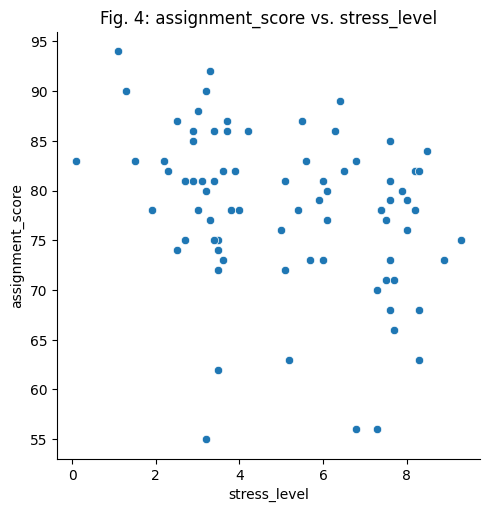

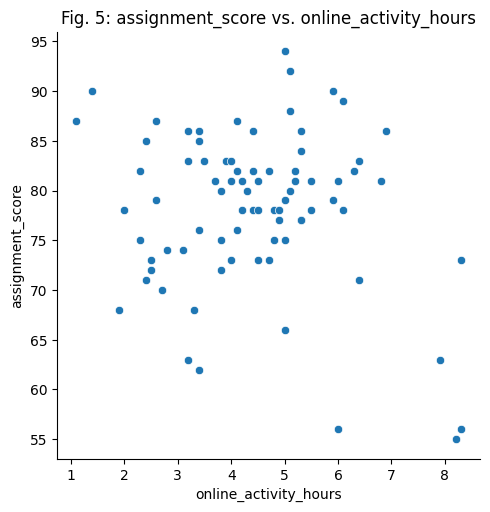

In [181]:
# Problem 1d)
i = 1
for column in df.columns.drop(['student_id', 'assignment_score']):
  sns.relplot(data=df, x=column, y='assignment_score')
  plt.title(f'Fig. {i}: assignment_score vs. {column}')
  i += 1


In [182]:
# Problem 1e)
for column in df.columns.drop(['student_id', 'assignment_score']):
  corr = df[column].corr(df['assignment_score'])
  print(f'Correlation between {column} and assignment_score: {corr:.2f}')


Correlation between attendance_percent and assignment_score: 0.82
Correlation between study_hours_per_week and assignment_score: 0.78
Correlation between motivation_level and assignment_score: 0.55
Correlation between stress_level and assignment_score: -0.33
Correlation between online_activity_hours and assignment_score: -0.18


Problem 1f)

Attendance percentage is highly positively correlated with getting high scores on assignments, as is the amount of study hours per week. Also positively correlated with high scores, though less so, is motivation level. Stress level is negatively correlated with getting high scores, as is time spent online, though only weakly. From this, we can conclude the most important thing one can do to optimize assignment score is keep their attendance high and study as much as possible. It is also important to stay motivated and reduce stress.

In [183]:
from sklearn import metrics

In [184]:
df2 = pd.read_csv('data-a2-p2.csv')
df2.head()

,student_id,passing_course,model_1_score,model_2_score
0,T001,1,0.848,1.000
1,T002,1,0.656,0.713
2,T003,1,0.823,1.000
3,T004,1,0.403,0.847
4,T005,1,0.523,0.636


Text(0.5, 1.0, 'Model 2 Confusion Matrix')

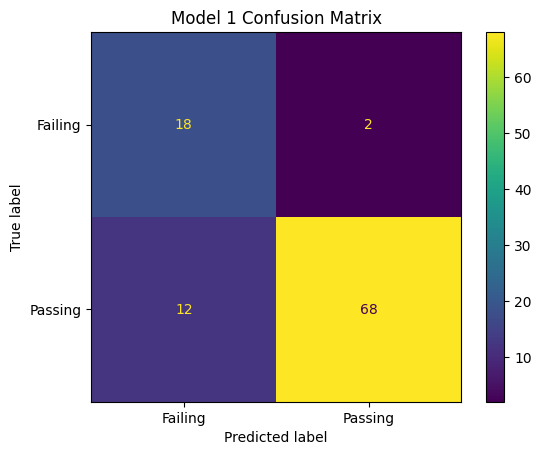

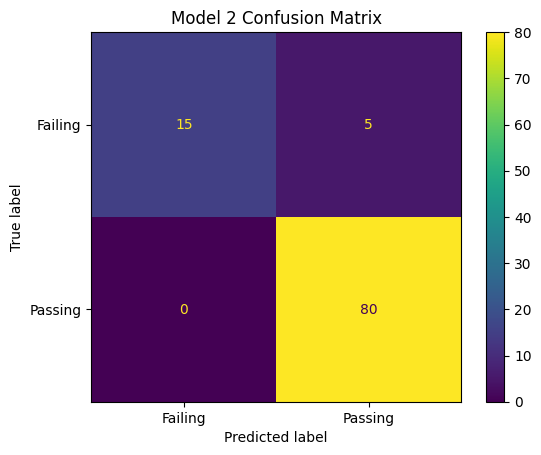

In [185]:
# Problem 2a)
df_thresh = df2.copy()
df_thresh['failing_course'] = (df2['passing_course'] != 1).astype(int)

df_thresh['model_1_prediction'] = (df2['model_1_score'] <= 0.5).astype(int)
df_thresh['model_2_prediction'] = (df2['model_2_score'] <= 0.5).astype(int)

cm1 = metrics.confusion_matrix(df_thresh['failing_course'], df_thresh['model_1_prediction'], labels= [1, 0])
cm1_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm1, display_labels = ['Failing', 'Passing'])
cm1_display.plot()
plt.title("Model 1 Confusion Matrix")

cm2 = metrics.confusion_matrix(df_thresh['failing_course'], df_thresh['model_2_prediction'], labels= [1, 0])
cm2_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm2, display_labels = ['Failing', 'Passing'])
cm2_display.plot()
plt.title("Model 2 Confusion Matrix")


In [186]:
# Problem 2b)
tp1, fn1, fp1, tn1 = cm1.ravel().tolist()

m1_acc = (tp1 + tn1) / (tp1 + tn1 + fp1 + fn1)

m1_l1_recall = tp1 / (tp1+fn1)
m1_l2_recall = tn1 / (tn1+fp1)
m1_aca = 1/2 * (m1_l1_recall + m1_l2_recall)
m1_acahm = 1 / (1/2 * (1/m1_l1_recall + 1/m1_l2_recall))
print("Model 1 has the following metrics:")
print(f"-Simple Accuracy: {m1_acc:.2f}")
print(f"-Average Class Accuracy: {m1_aca:.2f}")
print(f"-Average Class Harmonic Mean Accuracy: {m1_acahm:.2f}\n")

tp2, fn2, fp2, tn2 = cm2.ravel().tolist()

m2_acc = (tp2 + tn2) / (tp2 + tn2 + fp2 + fn2)

m2_l1_recall = tp2 / (tp2+fn2)
m2_l2_recall = tn2 / (tn2+fp2)
m2_aca = 1/2 * (m2_l1_recall + m2_l2_recall)
m2_acahm = 1 / (1/2 * (1/m2_l1_recall + 1/m2_l2_recall))
print("Model 2 has the following metrics:")
print(f"-Simple Accuracy: {m2_acc:.2f}")
print(f"-Average Class Accuracy: {m2_aca:.2f}")
print(f"-Average Class Harmonic Mean Accuracy: {m2_acahm:.2f}")

Model 1 has the following metrics:
-Simple Accuracy: 0.86
-Average Class Accuracy: 0.88
-Average Class Harmonic Mean Accuracy: 0.87

Model 2 has the following metrics:
-Simple Accuracy: 0.95
-Average Class Accuracy: 0.88
-Average Class Harmonic Mean Accuracy: 0.86


Problem 2c)

Model 2 would appear to perform better, with much higher simple accuracy and relatively equal average class accuracies. It must be noted that all three of these metrics consider each feature class as equally important.

In [187]:
# Problem 2d)
m1_precision = tp1 / (tp1 + fp1)
m1_recall = m1_l1_recall
print("Further Model 1 Metrics:")
print(f"-Precision: {m1_precision:.2f}")
print(f"-Recall: {m1_recall:.2f}")

m2_precision = tp2 / (tp2 + fp2)
m2_recall = m2_l1_recall
print("Further Model 2 Metrics:")
print(f"-Precision: {m2_precision:.2f}")
print(f"-Recall: {m2_recall:.2f}")



Further Model 1 Metrics:
-Precision: 0.60
-Recall: 0.90
Further Model 2 Metrics:
-Precision: 1.00
-Recall: 0.75


We calculate, for Model 1, a precision of 0.6 and a recall of 0.9. For Model 2, we calculate a precision of 1 and a recall of 0.75. From these metrics, we can determine that Model 1 is, for our purposes, superior, due to its higher recall. Recall can be contextualized as how confident we can be that all students that need help are identified; given the purpose of the model is to identify struggling students, it is clear we must maximize this metric. Precision, on the other hand, is contextualized as how confident we are that when our model classifies a student as struggling, they actually are struggling. This is important, but less so.

Text(0.5, 1.0, 'precision vs. recall for two models using a range of thresholds')

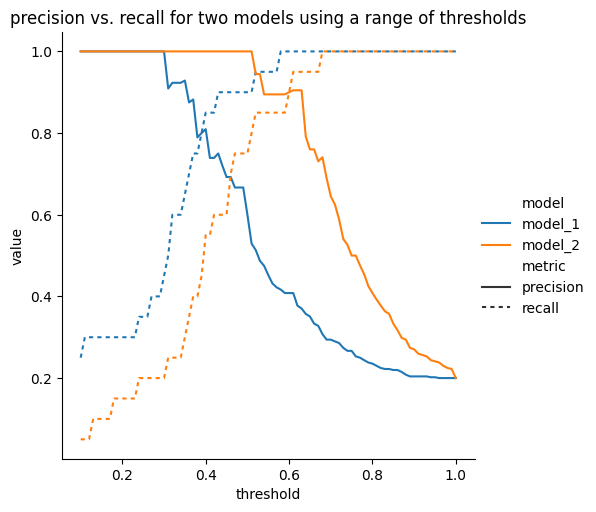

In [188]:
# Problem 2e)
df_thresh_range = pd.DataFrame(columns=['model', 'threshold', 'precision', 'recall'])
df_rates = pd.DataFrame(columns=['model', 'threshold', 'tp_rate', 'fp_rate'])
for i in np.round(np.linspace(0.1, 1.0, 101), 2):
  df_thresh['model_1_prediction'] = (df2['model_1_score'] <= i).astype(int)
  df_thresh['model_2_prediction'] = (df2['model_2_score'] <= i).astype(int)
  cm1 = metrics.confusion_matrix(df_thresh['failing_course'], df_thresh['model_1_prediction'], labels= [1, 0])
  cm2 = metrics.confusion_matrix(df_thresh['failing_course'], df_thresh['model_2_prediction'], labels= [1, 0])

  tp1, fn1, fp1, tn1 = cm1.ravel().tolist()

  # for problem 2i)
  df_rates.loc[len(df_rates)] = ['model_1', i, tp1 / (tp1+fn1), fp1 / (tp1+fp1)]
  df_rates.loc[len(df_rates)] = ['model_2', i, tp2 / (tp2+fn2), fp2 / (tn2+fp2)]


  m1_recall = tp1 / (tp1+fn1)
  if (tp1 + fp1 != 0):
    m1_precision = tp1 / (tp1 + fp1)
  else:
    m1_precision = 1
  df_thresh_range.loc[len(df_thresh_range)] = ['model_1', i, m1_precision, m1_recall]

  tp2, fn2, fp2, tn2 = cm2.ravel().tolist()
  m2_recall = tp2 / (tp2+fn2)
  if (tp2 + fp2 != 0):
    m2_precision = tp2 / (tp2 + fp2)
  else:
    m2_precision = 1

  df_thresh_range.loc[len(df_thresh_range)] = ['model_2', i, m2_precision, m2_recall]

df_temp = df_thresh_range.melt(
    id_vars=["threshold", "model"],
    value_vars=["precision", "recall"],
    var_name="metric",
    value_name="value"
)

sns.relplot(
    data=df_temp,
    x="threshold",
    y="value",
    hue="model",
    kind="line",
    style="metric",
    dashes={"precision": "", "recall": (2, 2)}
)

plt.title("precision vs. recall for two models using a range of thresholds")




From these curves, we can determine that Model 2 is preferable. Although Model 1 is better in terms of recall, Model 2 can still perform perfectly at high threshold values, while being vastly more precise.

Problem 2f)

To minimize the warnings wrongly given to students, I would choose the threshold which corresponds to a precision of 1 or very close to 1, and otherwise the highest possible recall. Conversely, to ensure a warning is not missed for a failing student, I would choose the threshold which corresponds to a recall of 1 or very near and otherwise the highest possible precision. Based on these criteria, I would suggest using Model 2, as both looking at the graph, our best choices are:
- Precision = 1, Recall ~= 0.5 (Model 1)
- Precision = 1, Recall ~= 0.8 (Model 2)
- Precision ~= 0.4, Recall ~= 1 (Model 1)
- Precision ~= 0.7, Recall ~= 1 (Model 2)

Clearly Model 2 maximizes our values for precision and recall.

Problem 2g)

I would choose the same points as above for the same reasons. For identifying those with failing potentials, a threshold of ~0.68. To give the least number of false warnings, a threshold of ~0.51. In both cases, I would use Model 2.


[Text(0.5, 0, 'Decile'), Text(0, 0.5, 'Cumulative Gain')]

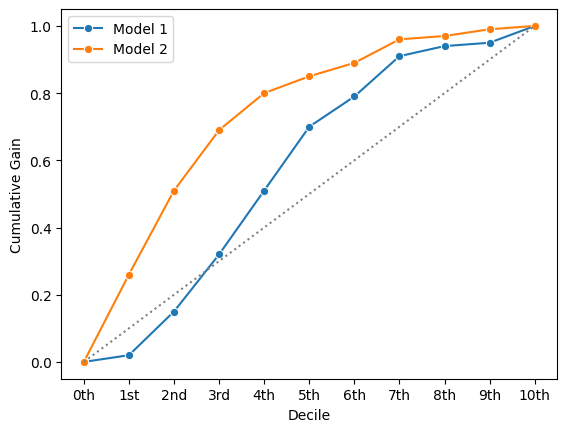

In [189]:
# Problem 2h)
positive_instances = df_thresh["failing_course"].sum()

df_thresh["model_1_score_inv"] = 1 - df_thresh["model_1_score"]
df_thresh["model_2_score_inv"] = 1 - df_thresh["model_2_score"]

m1_deciles = pd.cut(df_thresh["model_1_score_inv"], [-0.1, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.01],
                    right=False)
m1_deciles = m1_deciles.value_counts().sort_index()
m1_deciles = m1_deciles.cumsum() / m1_deciles.sum()

m2_deciles = pd.cut(df_thresh["model_2_score_inv"], [-0.1, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.01],
                    right=False)
m2_deciles = m2_deciles.value_counts().sort_index()
m2_deciles = m2_deciles.cumsum() / m2_deciles.sum()

x = ["0th", "1st", "2nd", "3rd", "4th", "5th", "6th", "7th", "8th", "9th", "10th"]
ax = sns.lineplot(x=x, y=m1_deciles, label="Model 1", marker="o")
sns.lineplot(x=x, y=m2_deciles, label="Model 2", ax=ax, marker="o")
sns.lineplot(x=["0th", "10th"], y=[0, 1], linestyle=":", color="grey", ax=ax)

ax.set(xlabel="Decile", ylabel="Cumulative Gain")

Model 2 is again better.

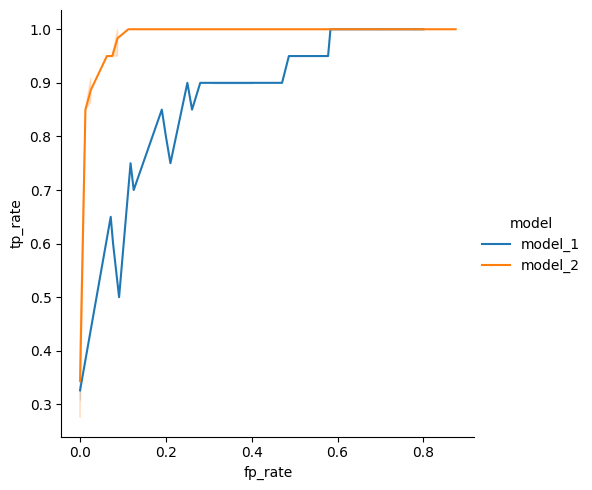

In [190]:
# Problem 2)

ax = sns.relplot(data=df_rates, x="fp_rate", y="tp_rate", hue="model", kind="line")

Problem 2j)

Based on the cumulative gain plot, I would again recommend Model 2 to the professor. At around the 6th - 7th decile, it can be seen Model 2 has already correctly identified 90% of the failing students, whereas Model 1 reaches this mark around the 8th decile.